# Gen-Z College Admission Dataset

### Importing all the necessary libraries


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Loading the dataset

In [4]:
import csv
df = pd.read_csv('/content/genz_college_admission_prediction.csv')


### Checking the features of the dataset

In [5]:
df.head()

,student_id,age,gender,state,family_income,high_school_gpa,sat_score,act_score,attendance_rate,ap_courses,extracurricular_count,volunteer_hours,leadership_positions,coding_projects,social_media_hours,online_certifications,essay_score,recommendation_score,interview_score,admission_status
0,1,22,Male,Ohio,32560,3.20,734,27,91.0,3,3,85,1,4,4.8,1,96.3,90.5,71.7,1
1,2,19,Male,Virginia,39084,4.00,988,26,100.0,0,5,103,1,4,2.7,2,59.9,55.2,93.0,1
2,3,20,Male,Ohio,21615,2.90,1600,28,97.7,2,3,78,2,1,5.4,4,75.2,70.3,70.0,1
3,4,22,Male,Illinois,109493,3.86,1302,28,91.6,4,3,98,0,2,1.8,2,80.7,81.9,98.7,1
4,5,18,Male,Florida,50314,2.50,1342,30,91.8,3,4,35,1,2,5.8,3,63.1,73.7,67.5,1


In [6]:
df.shape

(1000000, 20)

In [7]:
df.columns

Index(['student_id', 'age', 'gender', 'state', 'family_income',
       'high_school_gpa', 'sat_score', 'act_score', 'attendance_rate',
       'ap_courses', 'extracurricular_count', 'volunteer_hours',
       'leadership_positions', 'coding_projects', 'social_media_hours',
       'online_certifications', 'essay_score', 'recommendation_score',
       'interview_score', 'admission_status'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   student_id             1000000 non-null  int64  
 1   age                    1000000 non-null  int64  
 2   gender                 1000000 non-null  object 
 3   state                  1000000 non-null  object 
 4   family_income          1000000 non-null  int64  
 5   high_school_gpa        1000000 non-null  float64
 6   sat_score              1000000 non-null  int64  
 7   act_score              1000000 non-null  int64  
 8   attendance_rate        1000000 non-null  float64
 9   ap_courses             1000000 non-null  int64  
 10  extracurricular_count  1000000 non-null  int64  
 11  volunteer_hours        1000000 non-null  int64  
 12  leadership_positions   1000000 non-null  int64  
 13  coding_projects        1000000 non-null  int64  
 14  social_media_hours 

📊 Dataset Description
This dataset contains information on 1000000 students with 20 features related to their academic background, extracurricular involvement, personal attributes, and admission outcomes. It is designed to study factors that influence college admission decisions.

Key Details
Rows: 1000000 (each row represents one student)

Columns: 20 (mix of numerical and categorical features)

Target variable: admission_status (whether the student was admitted or not)

Column Breakdown
Identifiers & Demographics:

student_id (unique identifier)

age (numeric)

gender (categorical: Male/Female/Other)

state (categorical: student’s home state)

Academic Performance:

high_school_gpa, sat_score, act_score

attendance_rate (percentage of classes attended)

ap_courses (number of advanced placement courses taken)

Extracurricular & Engagement:

extracurricular_count, volunteer_hours, leadership_positions

coding_projects, online_certifications

Personal Attributes:

social_media_hours (average daily usage)

essay_score, recommendation_score, interview_score

Outcome:

admission_status (final decision)

Notes
Only gender and state are categorical; all other features are numeric (int/float).

The dataset is well‑suited for predictive modeling (classification) and exploratory analysis.

Potential analyses include:

Distribution of academic scores and extracurricular activities

Correlation between features and admission outcomes

State‑wise or gender‑wise admission trends

## Data cleaning and Preperation

In [9]:
df.isna().sum()

,0
student_id,0
age,0
gender,0
state,0
family_income,0
high_school_gpa,0
sat_score,0
act_score,0
attendance_rate,0
ap_courses,0


Out of 1000000 rows only 3 null values are found in columns like recommendation_score , interview score and admission status it is okay to drop thos rows with null values as it is not even 1% of the total data

In [10]:
df.dropna(inplace=True)

In [11]:
df.isna().sum()

,0
student_id,0
age,0
gender,0
state,0
family_income,0
high_school_gpa,0
sat_score,0
act_score,0
attendance_rate,0
ap_courses,0


In [12]:
df.duplicated().sum()

np.int64(0)

There are no duplicate records found in any of the row

Since the admission status is an categorical value converting 1 and 0 to yes and no
where yes represent admitted and no represent not admitted

In [13]:
def status(value):
  if value==1:
    return 'yes'
  else:
    return 'no'
df['admission_status'] = df['admission_status'].map(status)

In [14]:
df.head()

,student_id,age,gender,state,family_income,high_school_gpa,sat_score,act_score,attendance_rate,ap_courses,extracurricular_count,volunteer_hours,leadership_positions,coding_projects,social_media_hours,online_certifications,essay_score,recommendation_score,interview_score,admission_status
0,1,22,Male,Ohio,32560,3.20,734,27,91.0,3,3,85,1,4,4.8,1,96.3,90.5,71.7,yes
1,2,19,Male,Virginia,39084,4.00,988,26,100.0,0,5,103,1,4,2.7,2,59.9,55.2,93.0,yes
2,3,20,Male,Ohio,21615,2.90,1600,28,97.7,2,3,78,2,1,5.4,4,75.2,70.3,70.0,yes
3,4,22,Male,Illinois,109493,3.86,1302,28,91.6,4,3,98,0,2,1.8,2,80.7,81.9,98.7,yes
4,5,18,Male,Florida,50314,2.50,1342,30,91.8,3,4,35,1,2,5.8,3,63.1,73.7,67.5,yes


In [43]:
df.describe()

,student_id,age,family_income,high_school_gpa,sat_score,act_score,attendance_rate,ap_courses,extracurricular_count,volunteer_hours,leadership_positions,coding_projects,social_media_hours,online_certifications,essay_score,recommendation_score,interview_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,19.000294,71701.069023,3.188329,1099.198467,23.468139,91.748151,2.999739,3.999927,99.452955,1.201223,1.999254,4.506180,1.997953,74.912247,77.954531,72.775141
std,288675.278933,1.999321,47253.555181,0.476299,217.409113,5.908590,5.526156,1.729285,2.001495,50.019098,1.095605,1.414804,1.790163,1.414445,11.805257,9.873768,14.522840
min,1.000000,16.000000,2124.000000,0.870000,400.000000,1.000000,63.200000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,17.600000,28.800000,0.500000
25%,250000.750000,17.000000,39953.000000,2.860000,952.000000,19.000000,88.000000,2.000000,3.000000,63.000000,0.000000,1.000000,3.300000,1.000000,66.900000,71.300000,62.800000
50%,500000.500000,19.000000,59877.000000,3.200000,1100.000000,24.000000,92.000000,3.000000,4.000000,91.000000,1.000000,2.000000,4.500000,2.000000,75.000000,78.000000,73.000000
75%,750000.250000,21.000000,89688.000000,3.540000,1248.000000,28.000000,96.000000,4.000000,5.000000,127.000000,2.000000,3.000000,5.700000,3.000000,83.100000,84.700000,83.100000
max,1000000.000000,22.000000,977775.000000,4.000000,1600.000000,36.000000,100.000000,12.000000,15.000000,517.000000,8.000000,11.000000,12.900000,12.000000,100.000000,100.000000,100.000000


## Data Analysis

#### Univariate Analysis

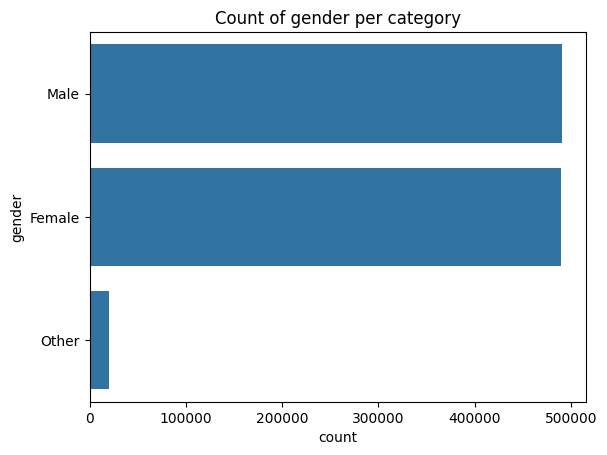

In [15]:
ax=sns.countplot(df['gender'])
sns.set_style('darkgrid')
sns.set_palette('muted')
plt.title('Count of gender per category')
gender_counts = df['gender'].value_counts()

In [16]:
gender_counts

,count
gender,
Male,490475
Female,489414
Other,20111


Gender Distribution
The dataset contains 1000000 students, with the following breakdown by gender:

Male: 490475 students (~49.1%)

Female: 489414 students (~48.9%)

Other: 20111 students (~2.0%) \
The data is balanced between Male and Female some students identify themself as other which is around 2% of the entire data

In [17]:
age_count=df['age'].value_counts()
age_count

,count
age,
20,143283
17,142976
19,142946
22,142788
18,142740
16,142639
21,142628


Text(0, 0.5, 'Count')

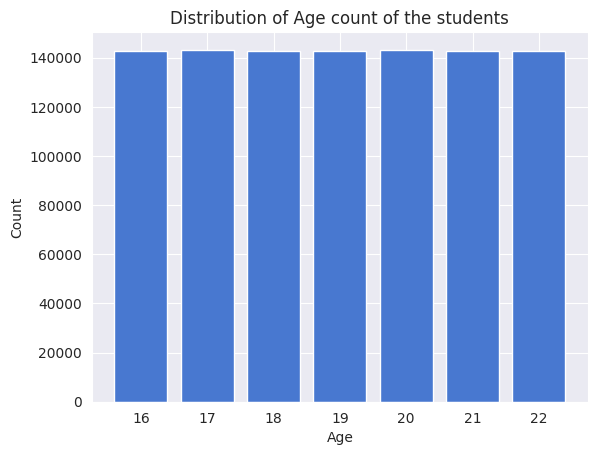

In [18]:
plt.title('Distribution of Age count of the students')
plt.bar(x=age_count.index,height=age_count.values)
plt.xlabel('Age')
plt.ylabel('Count')

Age Distribution
The dataset shows a uniform age distribution across students. For nearly every age group, there are approximately 140000 students, with only minor variations of about 400-500 students between ages.

✨ Key Insight
The distribution is flat and balanced, meaning no single age group dominates the dataset.

Small fluctuations (±400–500 students) are present, but they are not large enough to introduce bias.

This uniformity ensures that age is well-represented across the dataset

<Axes: xlabel='family_income', ylabel='Count'>

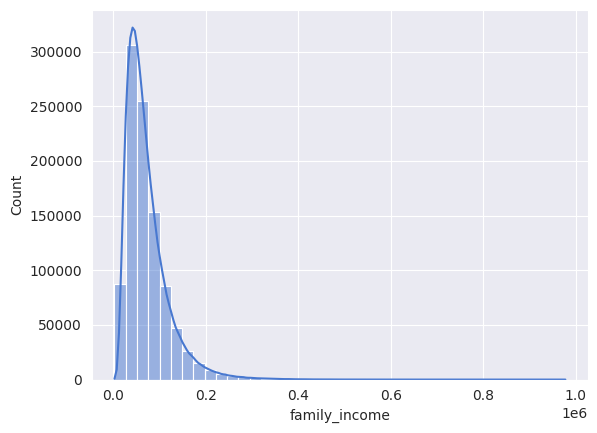

In [19]:
sns.histplot(df['family_income'],kde=True,bins=40)

The family income distribution is heavily right‑skewed, with most students’ families earning under $100,000 and a small proportion extending into very high income ranges. This indicates income inequality in the dataset and suggests that median values may better represent typical family income than the mean.

<Axes: xlabel='high_school_gpa', ylabel='Count'>

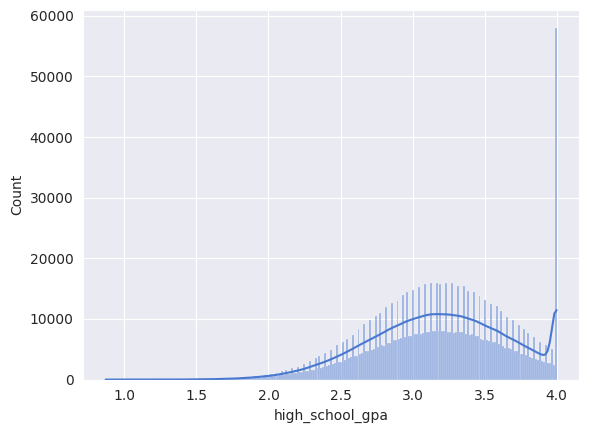

In [20]:
sns.histplot(df['high_school_gpa'],kde=True)

The distribution of high school GPA shows that most students score between 3.0 and 3.5, forming the central cluster of the dataset. Around 2,500 students achieved a perfect 4.0 GPA, creating a noticeable spike at the maximum value. This highlights both the typical performance range and the presence of a smaller group of exceptional achievers.




In [21]:
admitted_percentage = (df['admission_status'].value_counts()/len(df))*100
admitted_percentage

,count
admission_status,
yes,88.1292
no,11.8708


<Axes: xlabel='count', ylabel='admission_status'>

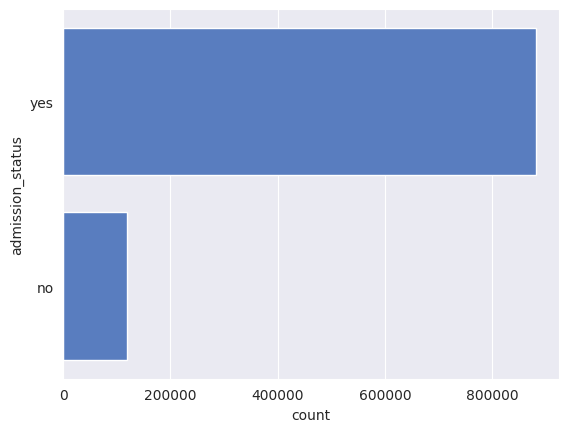

In [22]:
sns.countplot(df['admission_status'])

Around 88.54% of the students are admitted while 11.45% student are still not got admission

<Axes: xlabel='attendance_rate', ylabel='Count'>

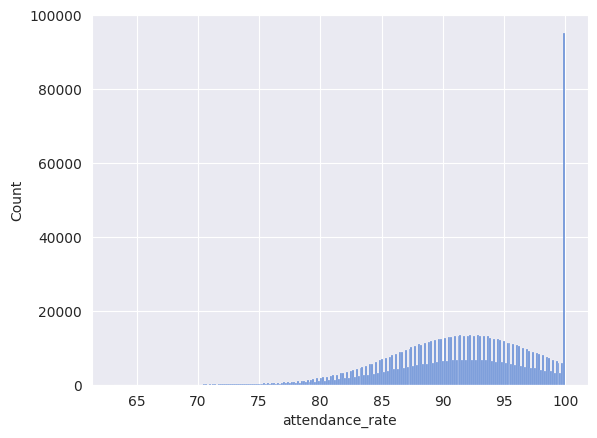

In [23]:
sns.histplot(df['attendance_rate'])

The attendance rate distribution reveals that most students maintain high attendance, clustering around 90–92%. A notable spike at 100% shows that many students achieved perfect attendance. This suggests that attendance is generally strong across the dataset, with very few cases of low participation.

In [24]:
certification_count=df['online_certifications'].value_counts().sort_index()/len(df)*100
certification_count

,count
online_certifications,
0,13.5916
1,27.0705
2,27.0474
3,18.0328
4,9.0153
5,3.5749
6,1.2177
7,0.3409
8,0.0835


<BarContainer object of 13 artists>

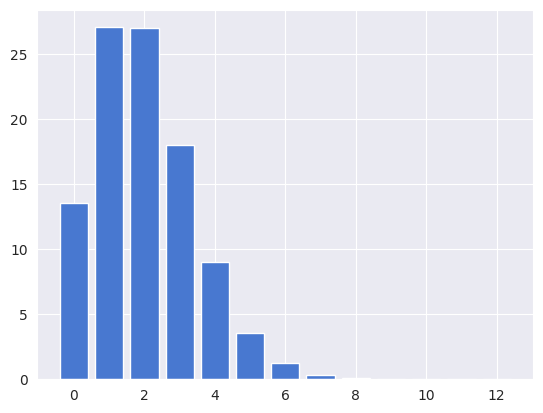

In [25]:
plt.bar(x=certification_count.index,height=certification_count.values)

The dataset shows how many online certification courses students have completed:

13% of students have not completed any certification.

27% of students have completed 1 certification course.

27% of students have completed 2 certification courses.

As the number of certifications increases beyond 2, the percentage of students steadily decreases.


In [26]:
state_count=df['state'].value_counts()
state_count

,count
state,
Illinois,100130
New York,100082
North Carolina,100070
Texas,100066
Washington,100024
Florida,100008
Virginia,99974
California,99938
Ohio,99934


Text(0, 0.5, 'Count')

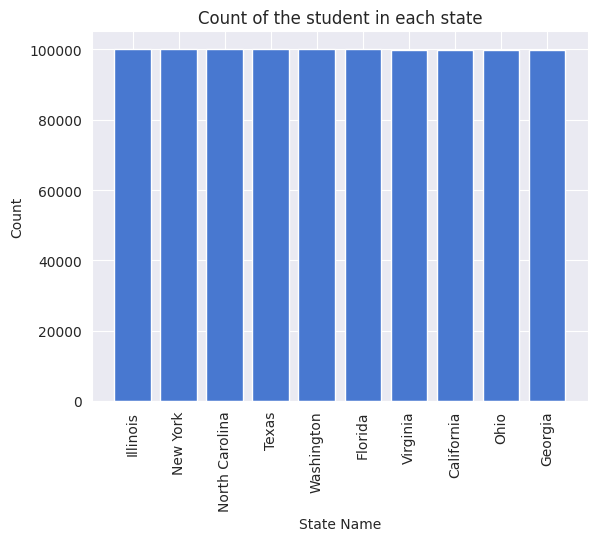

In [27]:
plt.title('Count of the student in each state')
plt.bar(x=state_count.index,height=state_count.values)
plt.xticks(rotation=90)
plt.xlabel('State Name')
plt.ylabel('Count')

The student are almost uniformly distributed across each state around 100000 students from each state
 with variation of around 0.5% to 1%

## Bivariate Analysis

<Axes: title={'center': 'Comparison of Admission count with gender'}, xlabel='admission_status', ylabel='count'>

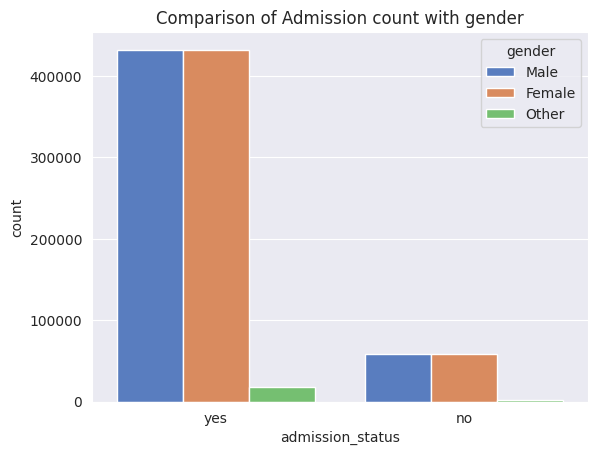

In [28]:
plt.title('Comparison of Admission count with gender')
sns.countplot(x=df['admission_status'],hue=df['gender'])

When comparing admission outcomes across male and female students, the data shows that gender does not play a significant role in the admission decision:

The number of admitted males and admitted females is nearly equal.

Similarly, the number of non‑admitted males and non‑admitted females is also almost equal.

This indicates that admission outcomes are balanced across genders, with no noticeable bias toward either group.

<Axes: xlabel='attendance_rate', ylabel='Density'>

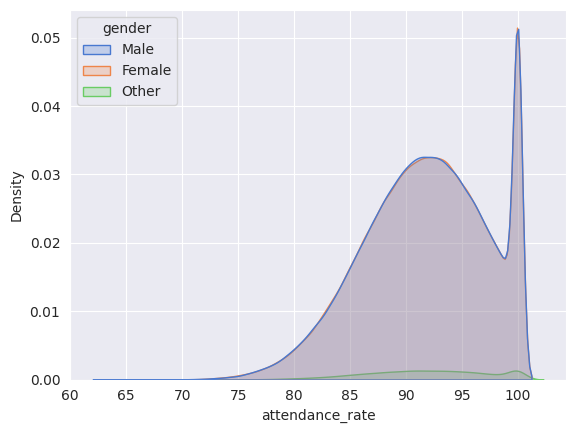

In [29]:
sns.kdeplot(x=df['attendance_rate'],hue=df['gender'],fill=True)

Attendance rate of male and females are similar

<Axes: >

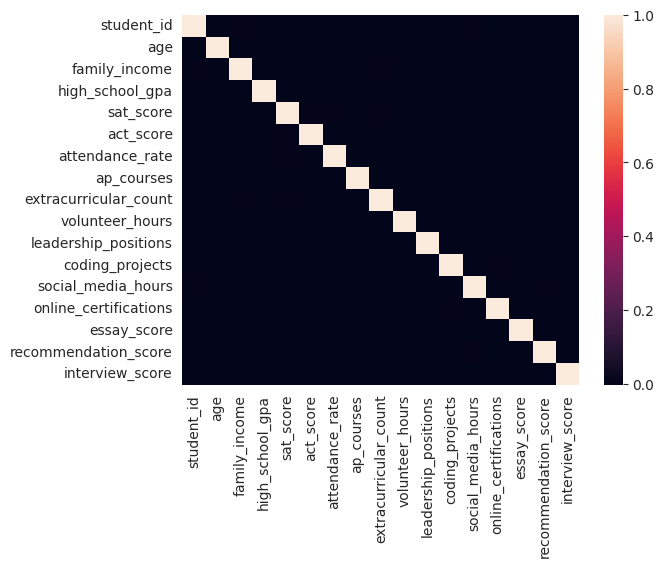

In [30]:
sns.heatmap(df.corr(numeric_only=True))

The correlation heatmap reveals that most student attributes are weakly correlated, indicating that each factor provides unique information about applicants.


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Ohio'),
  Text(1, 0, 'Virginia'),
  Text(2, 0, 'Illinois'),
  Text(3, 0, 'Florida'),
  Text(4, 0, 'California'),
  Text(5, 0, 'New York'),
  Text(6, 0, 'North Carolina'),
  Text(7, 0, 'Texas'),
  Text(8, 0, 'Georgia'),
  Text(9, 0, 'Washington')])

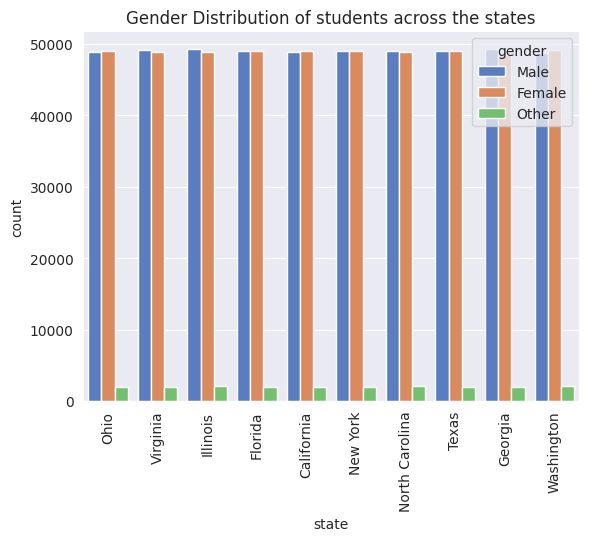

In [31]:
plt.title("Gender Distribution of students across the states")
sns.countplot(x=df['state'],hue=df['gender'])
plt.xticks(rotation=90)

In [32]:
pd.crosstab(index=df['state'],columns=df['gender'])

gender,Female,Male,Other
state,,,
California,49078,48916,1944
Florida,49004,49024,1980
Georgia,48523,49300,1951
Illinois,48829,49261,2040
New York,49031,49029,2022
North Carolina,48944,49054,2072
Ohio,48981,48941,2012
Texas,49007,49045,2014
Virginia,48811,49145,2018


So even in the states the gender distribution is uniform for male female and others

<Axes: xlabel='interview_score', ylabel='Density'>

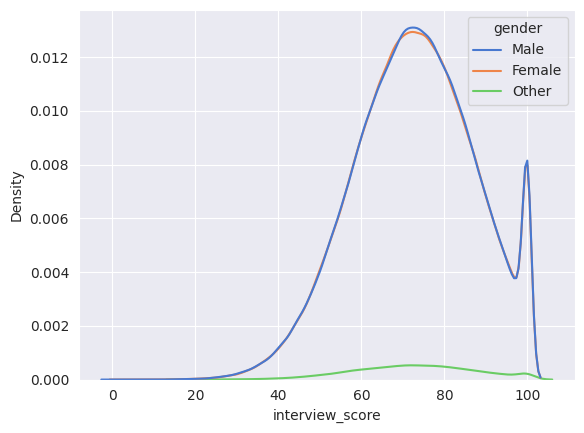

In [37]:
sns.kdeplot(x=df['interview_score'],hue=df['gender'])

The density plot of interview scores across gender categories shows that Male and Female students have nearly identical distributions, both peaking around scores of 75–80. This indicates that gender does not significantly affect interview performance for these groups. In contrast, the 'Other' category displays a flatter distribution, suggesting greater variability in scores. However, this difference may be influenced by the smaller sample size of students identifying as 'Other'.


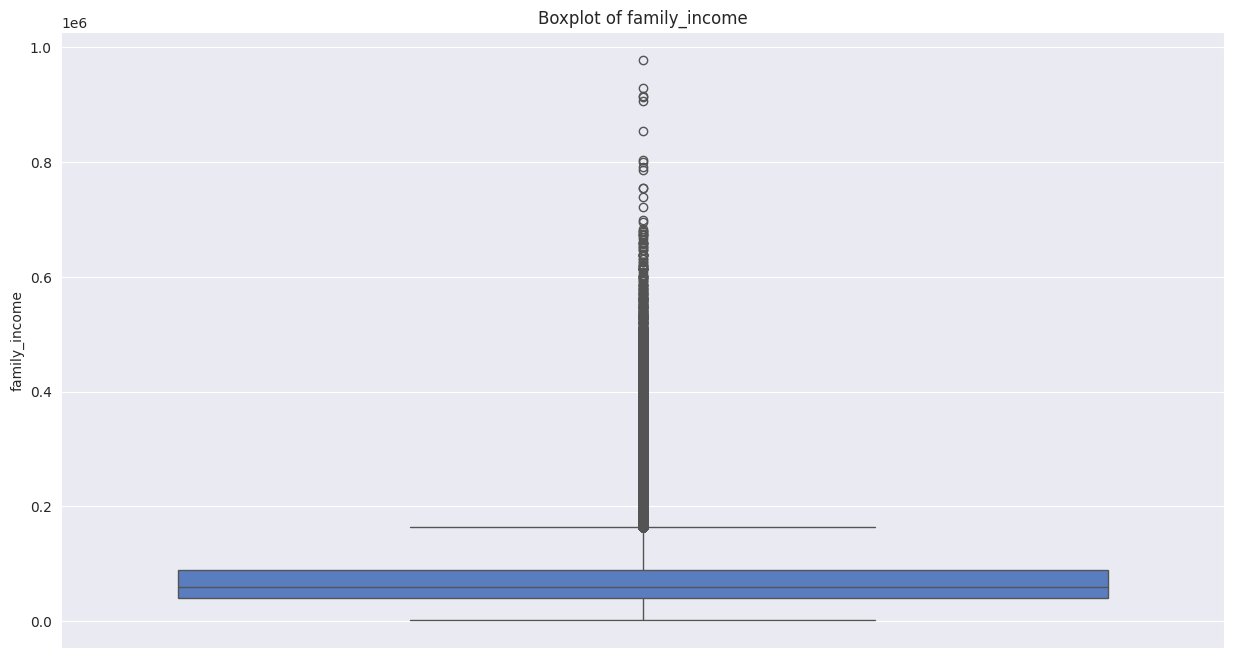

In [66]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(15,8))
sns.boxplot(data=df['family_income'])
plt.xticks(rotation=90)
plt.title("Boxplot of family_income")
plt.show()

The boxplot highlights that `family_income` contains numerous outliers on the higher end. This reflects the natural skewness of income data, where most families earn within a moderate range but a small proportion report very high incomes. These outliers are important to note, as they can disproportionately influence statistical measures like the mean. In such cases, the median often provides a more reliable measure of central tendency.


In [45]:
perfect_interview_score=df[df['interview_score']==100]

<Axes: xlabel='count', ylabel='gender'>

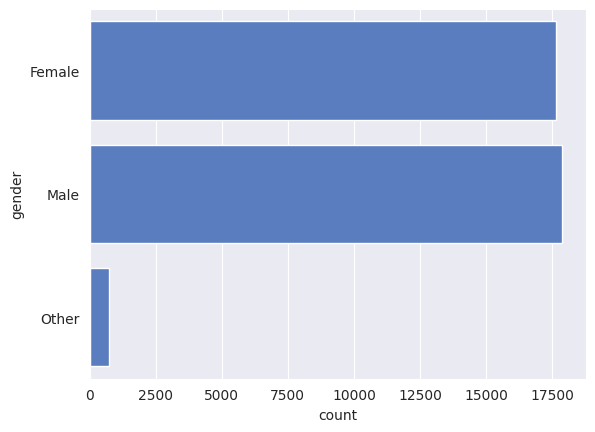

In [46]:
sns.countplot(perfect_interview_score['gender'])

In [62]:
perfect_gpa_score = df[df['high_school_gpa']==4]
low_gpa_score = df[df['high_school_gpa']<4]
low_gpa_score

,student_id,age,gender,state,family_income,high_school_gpa,sat_score,act_score,attendance_rate,ap_courses,extracurricular_count,volunteer_hours,leadership_positions,coding_projects,social_media_hours,online_certifications,essay_score,recommendation_score,interview_score,admission_status
0,1,22,Male,Ohio,32560,3.20,734,27,91.0,3,3,85,1,4,4.8,1,96.3,90.5,71.7,yes
2,3,20,Male,Ohio,21615,2.90,1600,28,97.7,2,3,78,2,1,5.4,4,75.2,70.3,70.0,yes
3,4,22,Male,Illinois,109493,3.86,1302,28,91.6,4,3,98,0,2,1.8,2,80.7,81.9,98.7,yes
4,5,18,Male,Florida,50314,2.50,1342,30,91.8,3,4,35,1,2,5.8,3,63.1,73.7,67.5,yes
5,6,20,Female,California,133840,3.81,949,26,94.0,0,2,217,0,1,2.7,2,70.1,81.3,76.8,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,999996,20,Female,New York,127978,3.98,984,27,94.9,3,6,24,1,2,3.9,2,72.6,76.0,82.0,yes
999996,999997,16,Male,Ohio,47661,3.49,940,25,80.6,2,4,206,1,3,6.7,0,88.5,72.9,67.4,yes
999997,999998,21,Female,Washington,88044,2.77,1103,16,95.9,0,1,67,0,2,3.7,3,73.1,85.9,77.6,yes
999998,999999,17,Female,Virginia,55654,3.71,1208,27,87.8,3,8,24,1,2,2.8,0,72.6,60.9,71.0,yes


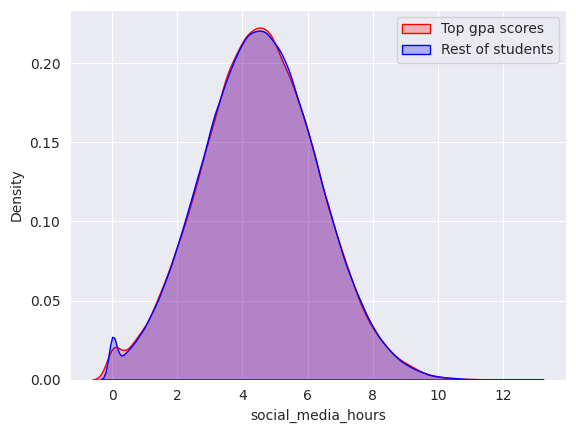

In [65]:
sns.kdeplot(perfect_gpa_score['social_media_hours'],fill=True,color='Red')
sns.kdeplot(low_gpa_score['social_media_hours'],fill=True,color='blue')
plt.legend(['Top gpa scores','Rest of students'])

The comparison of social media usage between top GPA students and the rest shows nearly identical distributions, both peaking around 4 hours per day. This indicates that social media usage does not significantly influence academic performance in this dataset. High-achieving students and others appear to spend similar amounts of time on social media, suggesting that GPA outcomes are driven more by other factors such as test scores, coursework, and extracurricular involvement.


In [ ]:
sns.pairplot(df)

## Numerical Analysis

In [68]:
df.describe()

,student_id,age,family_income,high_school_gpa,sat_score,act_score,attendance_rate,ap_courses,extracurricular_count,volunteer_hours,leadership_positions,coding_projects,social_media_hours,online_certifications,essay_score,recommendation_score,interview_score
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,500000.500000,19.000294,71701.069023,3.188329,1099.198467,23.468139,91.748151,2.999739,3.999927,99.452955,1.201223,1.999254,4.506180,1.997953,74.912247,77.954531,72.775141
std,288675.278933,1.999321,47253.555181,0.476299,217.409113,5.908590,5.526156,1.729285,2.001495,50.019098,1.095605,1.414804,1.790163,1.414445,11.805257,9.873768,14.522840
min,1.000000,16.000000,2124.000000,0.870000,400.000000,1.000000,63.200000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,17.600000,28.800000,0.500000
25%,250000.750000,17.000000,39953.000000,2.860000,952.000000,19.000000,88.000000,2.000000,3.000000,63.000000,0.000000,1.000000,3.300000,1.000000,66.900000,71.300000,62.800000
50%,500000.500000,19.000000,59877.000000,3.200000,1100.000000,24.000000,92.000000,3.000000,4.000000,91.000000,1.000000,2.000000,4.500000,2.000000,75.000000,78.000000,73.000000
75%,750000.250000,21.000000,89688.000000,3.540000,1248.000000,28.000000,96.000000,4.000000,5.000000,127.000000,2.000000,3.000000,5.700000,3.000000,83.100000,84.700000,83.100000
max,1000000.000000,22.000000,977775.000000,4.000000,1600.000000,36.000000,100.000000,12.000000,15.000000,517.000000,8.000000,11.000000,12.900000,12.000000,100.000000,100.000000,100.000000


`Family Income` - 50% of the students family have income less than 60000 USD
where in the family income the difference in mean and median shows potential outliers

`High School GPA` - around 25% of the student have gpa more than 3.5

`Age` - Students have age ranging from 16-22

`Attendance Rate` - over 75% of the students have attentance rate more than 88%

## Conclusions

Based on all the insights you've extracted, here is a concise **Final Conclusion and Key Findings** section that you can include in your EDA report:

### Final Conclusion

The exploratory data analysis of the student admission dataset reveals a well-balanced and diverse student population with minimal demographic bias. Gender and age distributions are uniformly represented, ensuring that no particular group dominates the dataset. Student representation across states is also evenly distributed, making the dataset suitable for unbiased analysis.

Academic performance indicators show that most students maintain a high school GPA between 3.0 and 3.5, while a smaller group achieves exceptional results with a perfect GPA. Attendance rates are generally high, with many students maintaining near-perfect attendance, indicating strong student engagement.

Family income exhibits a heavily right-skewed distribution with several high-income outliers, suggesting income inequality within the student population. Due to this skewness, median income is a more reliable measure than the mean for representing typical family earnings.

Admission outcomes are overwhelmingly positive, with approximately 88.5% of students receiving admission offers. Analysis across gender categories shows nearly identical admission rates and interview score distributions, indicating that gender does not significantly influence admission decisions or interview performance.

Certification completion patterns suggest that most students complete one or two online certifications, while participation declines as the number of certifications increases. Additionally, social media usage appears to have little to no relationship with academic performance, as both high-GPA students and other students exhibit similar usage patterns.

Correlation analysis indicates that most variables are only weakly related to one another, suggesting that each feature contributes unique information about students rather than being highly redundant.

### Key Findings

* Dataset contains **1,000,000 students** with balanced gender representation:

  * Male: ~49.1%
  * Female: ~48.9%
  * Other: ~2.0%

* Age distribution is nearly uniform, reducing age-related bias.

* Students are evenly distributed across states, with only minor variations.

* Family income is highly right-skewed, with significant high-income outliers.

* Most students have a GPA between **3.0 and 3.5**, while a smaller group achieves a perfect **4.0 GPA**.

* Attendance rates are generally high, clustering around **90–92%**, with many students achieving **100% attendance**.

* Approximately **88.54%** of students are admitted, while **11.45%** are not admitted.

* Admission outcomes are balanced across genders, indicating no noticeable gender-based bias.

* Male and female students exhibit similar attendance rates and interview score distributions.

* Most students complete **1–2 online certification courses**, with participation decreasing beyond that level.

* Social media usage shows little relationship with GPA, suggesting it is not a major factor influencing academic performance in this dataset.

* Most variables have weak correlations, meaning each feature provides distinct information about student characteristics and outcomes.

### Overall Finding

The dataset represents a balanced student population where **academic factors such as GPA, attendance, interview performance, and certifications appear more informative than demographic factors such as gender or state**. The analysis suggests that admission decisions are largely independent of demographic characteristics and are more closely associated with student performance-related attributes.
